## Imports

In [1]:
!pip uninstall -y tree-sitter tree-sitter-python tree-sitter-java codebleu tree-sitter-languages
!pip install tree-sitter==0.22.3
!pip install tree-sitter-python==0.21.0
!pip install tree-sitter-java==0.21.0
!pip install tree-sitter-languages==1.10.2
!pip install codebleu==0.7.0
!pip install gensim

from IPython.display import clear_output; clear_output()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm
from codebleu import calc_codebleu
from gensim.models import Word2Vec
from transformers import RobertaTokenizer, RobertaModel
import numpy as np
import json
import os

In [ ]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Configuration

**BATCH_SIZE = 32**: Number of buggy-fixed pairs the model sees in one training step. Larger batch = more stable gradients but more GPU memory.

**MAX_LEN = 100**: Maximum sequence length in tokens. The dataset is BFsmall (methods ≤ 50 tokens), so 100 gives enough room after adding SOS and EOS tokens.

**HIDDEN_DIM = 256**: The size of the LSTM's internal memory vector. At each time step, the LSTM compresses everything it has seen so far into a 256-dimensional vector. This is also the embedding size for Word2Vec mode.

![LSTM Hidden State](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)
*Source: [Understanding LSTMs - Christopher Olah](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)*

**NUM_EPOCHS = 10**: One epoch = one full pass over all 46,680 training samples. So 10 epochs means the model sees every sample 10 times. May stop earlier via early stopping.

**EVAL_STEPS = 500**: How often we evaluate on the validation set, derived from dataset size:

| | Value |
|---|---|
| Train samples | 46,680 |
| Batch size | 32 |
| Steps per epoch | 46,680 / 32 = **1,459** |
| Total steps (10 epochs) | 1,459 × 10 = **14,590** |
| Evals per epoch | 1,459 / 500 ≈ **3** |
| Total evals | 14,590 / 500 ≈ **29** |

In [ ]:
BATCH_SIZE = 32
MAX_LEN = 100
HIDDEN_DIM = 256
NUM_EPOCHS = 10
EVAL_STEPS = 500
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load and Explore Dataset

CodeXGLUE small dataset from Tufano et al. 2019. The code is already abstracted using [src2abs](https://github.com/micheletufano/src2abs).

**What src2abs does:** A Java Lexer tokenizes the raw code, then a Java Parser identifies the role of each identifier and literal and replaces them with typed IDs:

| Type | Example | Abstracted |
|---|---|---|
| Variables | `name`, `index` | `VAR_1`, `VAR_2` |
| Methods | `setName`, `toString` | `METHOD_1`, `METHOD_2` |
| Types | `String`, `ArrayList` | `TYPE_1`, `TYPE_2` |
| Literals | `"Hello"`, `42` | `STRING_1`, `INT_1` |

For example:
```
Raw:    public static void main(String[] args) { console.println("Hello, World!"); }
Abstract: public static void METHOD_1 ( TYPE_1 [ ] VAR_1 ) { VAR_2 . METHOD_2 ( STRING_1 ) ; }
```

**Why abstract?** Different developers use different names for the same logic. `setName`, `updateName`, `changeName` all do similar things but are three different tokens. After abstraction they all become `METHOD_1`, which drastically reduces vocabulary size and lets the model focus on structural patterns rather than memorizing variable names. This is critical for an LSTM with limited capacity -- smaller vocab means fewer parameters, less sparsity, and better generalization.

IDs are reused when the same identifier appears again in the code, so the model can still learn that the same variable is referenced in multiple places.

In [ ]:
dataset = load_dataset("google/code_x_glue_cc_code_refinement", name="small")

train_data = list(dataset['train'])
val_data = list(dataset['validation'])
test_data = list(dataset['test'])

print(f"Train: {len(train_data)}")
print(f"Val: {len(val_data)}")
print(f"Test: {len(test_data)}")

print("\n--- Sample ---")
print(f"Buggy: {train_data[0]['buggy']}")
print(f"Fixed: {train_data[0]['fixed']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

small/train-00000-of-00001.parquet:   0%|          | 0.00/4.72M [00:00<?, ?B/s]

small/validation-00000-of-00001.parquet:   0%|          | 0.00/591k [00:00<?, ?B/s]

small/test-00000-of-00001.parquet:   0%|          | 0.00/589k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/46680 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5835 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5835 [00:00<?, ? examples/s]

Train: 46680
Val: 5835
Test: 5835

--- Sample ---
Buggy: public java.lang.String METHOD_1 ( ) { return new TYPE_1 ( STRING_1 ) . format ( VAR_1 [ ( ( VAR_1 . length ) - 1 ) ] . getTime ( ) ) ; } 

Fixed: public java.lang.String METHOD_1 ( ) { return new TYPE_1 ( STRING_1 ) . format ( VAR_1 [ ( ( type ) - 1 ) ] . getTime ( ) ) ; } 



## Vocabulary

Two approaches depending on the embedding strategy:

- **Vocab** (for Word2Vec): whitespace tokenization, keeps tokens appearing 2+ times, rare tokens become `<UNK>`. Requires calling `build()` on training data first.
- **CodeBERTVocab** (for CodeBERT): wraps CodeBERT's BPE tokenizer, no OOV problem since unknown tokens get split into known sub-tokens. No `build()` needed — vocabulary is already pretrained.

Both share the same interface: `encode()` converts code into numbers, `decode()` converts numbers back into code.

**Special tokens:**

| Token | ID (Vocab) | ID (CodeBERT) | Purpose |
|---|---|---|---|
| PAD | 0 | 1 | Padding shorter sequences in a batch |
| SOS/BOS | 1 | 0 | Signals the decoder to start generating |
| EOS | 2 | 2 | Signals the decoder to stop generating |
| UNK | 3 | N/A | Replaces rare tokens (CodeBERT has no UNK since BPE splits everything) |

**Quick reminder on BPE (Byte-Pair Encoding):** CodeBERT doesn't tokenize by whitespace. Instead, BPE breaks tokens into smaller known sub-pieces. For example:
```
Whitespace: "getMinElement" → ["getMinElement"] → UNK (not in vocab)
BPE:        "getMinElement" → ["get", "Min", "Element"] → all known tokens
```
This is why CodeBERTVocab has no UNK -- every word can be decomposed into pieces the tokenizer already knows.

In [ ]:
class Vocab:
    def __init__(self):
        # start with 4 special tokens, real tokens added by build()
        self.token2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, "<UNK>": 3}
        self.idx2token = {}

    def build(self, data):
        counter = Counter()
        for sample in data:
            counter.update(sample['buggy'].split() + sample['fixed'].split()) # count how often each token appears

        idx = 4 # start after special tokens
        for token, count in counter.items():
            if count >= 2: # ignore rare tokens, they become UNK
                self.token2idx[token] = idx
                idx += 1

        self.idx2token = {v: k for k, v in self.token2idx.items()} # reverse mapping to convert predicted ids back into tokens

    def save(self, path):
        with open(path, 'w') as f:
            json.dump(self.token2idx, f)
        print(f"Vocab saved to {path}")

    def load(self, path):
        with open(path, 'r') as f:
            self.token2idx = json.load(f)
        self.idx2token = {v: k for k, v in self.token2idx.items()}
        print(f"Vocab loaded from {path} ({len(self.token2idx)} tokens)")

    def encode(self, text):
        tokens = [1] + [self.token2idx.get(t, 3) for t in text.split()[:98]] + [2]
        return tokens

    def decode(self, indices):
        return ' '.join([self.idx2token.get(i, '') for i in indices if i not in [0, 1, 2]]) # skip special tokens

    def __len__(self):
        return len(self.token2idx)


class CodeBERTVocab:
    def __init__(self):
        self.tokenizer = RobertaTokenizer.from_pretrained('microsoft/codebert-base')
        self.pad_id = self.tokenizer.pad_token_id
        self.sos_id = self.tokenizer.bos_token_id
        self.eos_id = self.tokenizer.eos_token_id

    def encode(self, text):
        encoded = self.tokenizer.encode(
            text, max_length=MAX_LEN, truncation=True, add_special_tokens=True
        )
        return encoded

    def decode(self, indices):
        filtered = [i for i in indices if i not in [self.pad_id, self.sos_id, self.eos_id]]
        return self.tokenizer.decode(filtered, clean_up_tokenization_spaces=True)

    def __len__(self):
        return len(self.tokenizer)

## Dataset and DataLoader

The CodeXGLUE bug-fixing dataset comes in two sizes based on method token length:

| Split | Token Limit | Train | Val | Test |
|---|---|---|---|---|
| BFsmall | ≤ 50 tokens | 46,680 | 5,835 | 5,835 |
| BFmedium | 50-100 tokens | 52,364 | 6,545 | 6,545 |

We use **BFsmall** since shorter methods are easier for LSTM to learn (Tufano et al. reported 26.66% accuracy on small vs 12.07% on medium).

`BugDataset` encodes each buggy-fixed pair into token IDs using the vocabulary. `collate_fn` pads all sequences in a batch to the length of the longest sequence in that batch.

In [ ]:
class BugDataset(Dataset):
    def __init__(self, data, vocab):
        self.data = data
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (torch.tensor(self.vocab.encode(self.data[idx]['buggy'])),
                torch.tensor(self.vocab.encode(self.data[idx]['fixed'])))

def collate_fn(batch):
    buggy, fixed = zip(*batch)
    return (pad_sequence(buggy, batch_first=True), # batch True = (batch_size, max_sequence_length_in_this_batch)
            pad_sequence(fixed, batch_first=True))

## Embedding Strategies

### Word2Vec (CBOW)

We train Word2Vec using **CBOW (Continuous Bag of Words)** mode (`sg=0`), which predicts a target token from its surrounding context window. The alternative is **Skip-gram** (`sg=1`), which predicts surrounding words from the target. CBOW works better for frequent tokens and is faster to train — a good fit for our repetitive abstracted code.

Training parameters: `window=5` (context of 5 tokens on each side), `min_count=2` (ignore tokens appearing once), `epochs=10`.

**Why not use a pretrained Word2Vec (like Google News)?** Our dataset uses abstracted tokens like `METHOD_1`, `VAR_1`, `TYPE_1`. These don't exist in any pretrained model. Run the demo below to see.

### CodeBERT

Extracts the pretrained embedding layer from `microsoft/codebert-base`. These vectors were learned from millions of code files across 6 languages. We freeze them (no gradient updates) and project from 768-dim down to 256-dim to match our LSTM hidden size.

### Demo: Pretrained vs Corpus-Trained Word2Vec

In [ ]:
import gensim.downloader as api
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# download pretrained Google News Word2Vec (~1.7GB, takes a minute)
print("Loading pretrained Google News Word2Vec...")
pretrained_w2v = api.load('word2vec-google-news-300')

# train Word2Vec on our code corpus
print("Training Word2Vec on code corpus...")
sentences = []
for sample in train_data:
    sentences.append(sample['buggy'].split())
    sentences.append(sample['fixed'].split())
corpus_w2v = Word2Vec(sentences=sentences, vector_size=256, window=5, min_count=2, epochs=10, sg=0)
print("Done!")

Loading pretrained Google News Word2Vec...
[=======================---------------------------] 47.7% 792.5/1662.8MB downloaded


KeyboardInterrupt



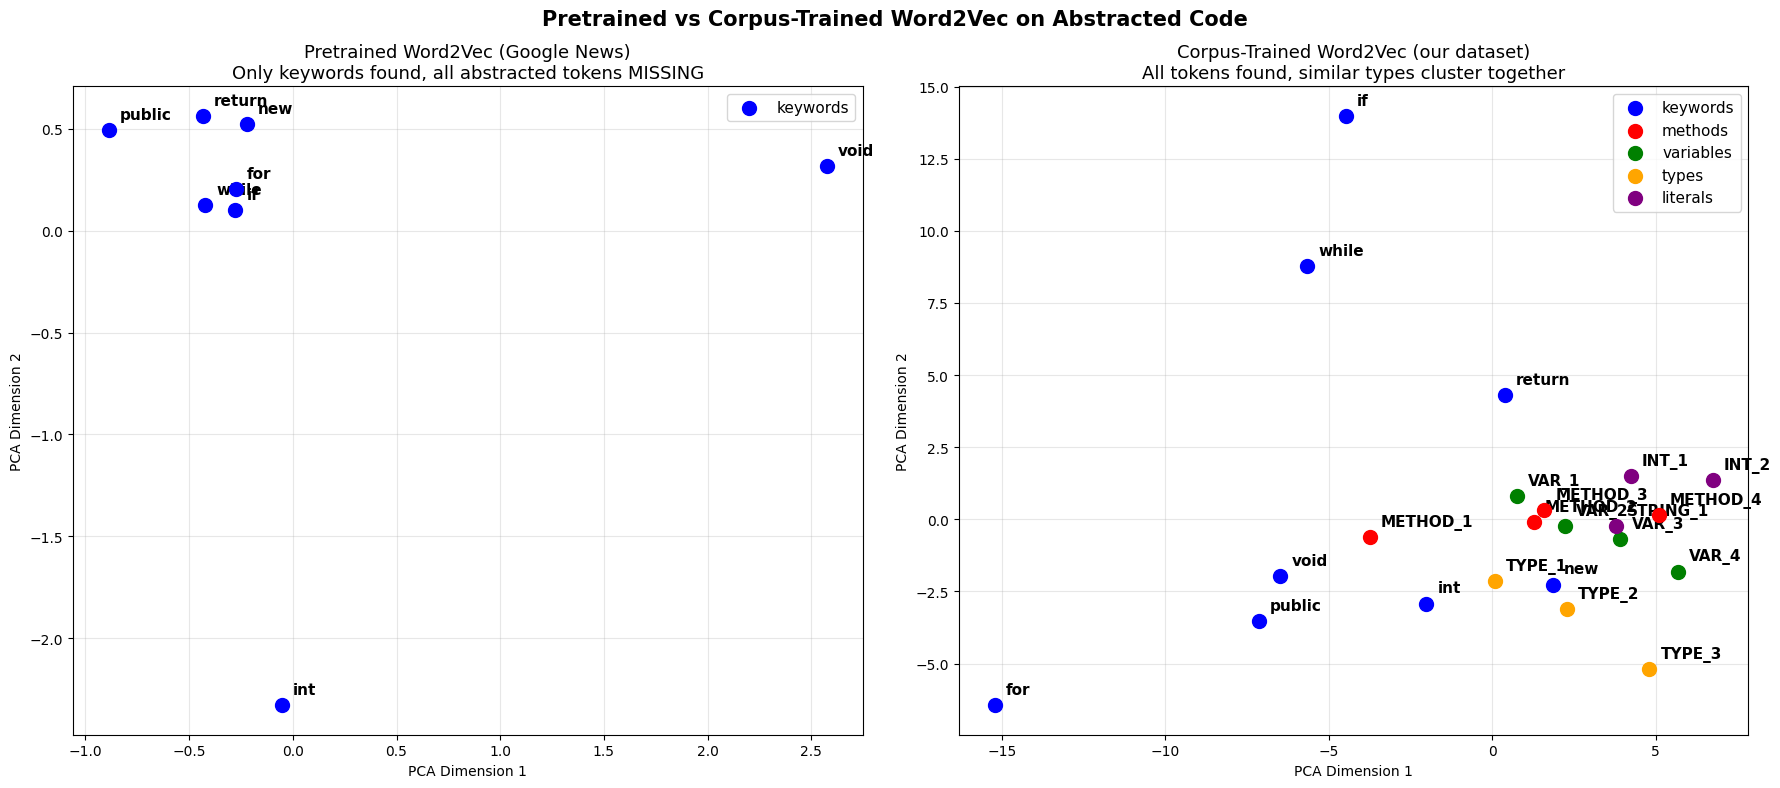

In [ ]:
token_groups = {
    'keywords':    ['public', 'void', 'return', 'int', 'if', 'for', 'while', 'new'],
    'methods':     ['METHOD_1', 'METHOD_2', 'METHOD_3', 'METHOD_4'],
    'variables':   ['VAR_1', 'VAR_2', 'VAR_3', 'VAR_4'],
    'types':       ['TYPE_1', 'TYPE_2', 'TYPE_3'],
    'literals':    ['STRING_1', 'INT_1', 'INT_2'],
}

group_colors = {
    'keywords': 'blue', 'methods': 'red', 'variables': 'green',
    'types': 'orange', 'literals': 'purple',
}

# collect tokens for pretrained (only keywords exist)
pre_tokens, pre_labels, pre_vecs = [], [], []
for group, token_list in token_groups.items():
    for t in token_list:
        if t in pretrained_w2v:
            pre_tokens.append(t)
            pre_labels.append(group)
            pre_vecs.append(pretrained_w2v[t])

# collect tokens for corpus-trained (all exist)
corp_tokens, corp_labels, corp_vecs = [], [], []
for group, token_list in token_groups.items():
    for t in token_list:
        if t in corpus_w2v.wv:
            corp_tokens.append(t)
            corp_labels.append(group)
            corp_vecs.append(corpus_w2v.wv[t])

pca_pre = PCA(n_components=2).fit_transform(np.array(pre_vecs))
pca_corp = PCA(n_components=2).fit_transform(np.array(corp_vecs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# left: pretrained (only keywords, no abstracted tokens)
for group in group_colors:
    mask = [l == group for l in pre_labels]
    if any(mask):
        xs = pca_pre[mask, 0]
        ys = pca_pre[mask, 1]
        ax1.scatter(xs, ys, c=group_colors[group], label=group, s=100, zorder=5)
for i, token in enumerate(pre_tokens):
    ax1.annotate(token, (pca_pre[i, 0], pca_pre[i, 1]),
                fontsize=11, fontweight='bold', xytext=(8, 8), textcoords='offset points')
ax1.set_title('Pretrained Word2Vec (Google News)\nOnly keywords found, all abstracted tokens MISSING', fontsize=13)
ax1.set_xlabel('PCA Dimension 1')
ax1.set_ylabel('PCA Dimension 2')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# right: corpus-trained (all tokens, clear clustering)
for group in group_colors:
    mask = [l == group for l in corp_labels]
    if any(mask):
        xs = pca_corp[mask, 0]
        ys = pca_corp[mask, 1]
        ax2.scatter(xs, ys, c=group_colors[group], label=group, s=100, zorder=5)
for i, token in enumerate(corp_tokens):
    ax2.annotate(token, (pca_corp[i, 0], pca_corp[i, 1]),
                fontsize=11, fontweight='bold', xytext=(8, 8), textcoords='offset points')
ax2.set_title('Corpus-Trained Word2Vec (our dataset)\nAll tokens found, similar types cluster together', fontsize=13)
ax2.set_xlabel('PCA Dimension 1')
ax2.set_ylabel('PCA Dimension 2')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Pretrained vs Corpus-Trained Word2Vec on Abstracted Code', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def train_word2vec(train_data, vocab, embed_dim):
    print("Training Word2Vec on code corpus...")

    sentences = []
    for sample in train_data:
        sentences.append(sample['buggy'].split())
        sentences.append(sample['fixed'].split())

    # window=5: looks at 5 tokens on each side of the target
    w2v_model = Word2Vec(
        sentences=sentences, vector_size=embed_dim,
        window=5, min_count=2, workers=4, epochs=10, sg=0
    )
    print(f"Word2Vec trained: {len(w2v_model.wv)} word vectors")

    # create embedding matrix matching our vocab indices
    # random init for tokens Word2Vec didn't learn (e.g., SOS, EOS, UNK)
    vocab_size = len(vocab)
    embedding_matrix = np.random.normal(0, 0.1, (vocab_size, embed_dim))
    embedding_matrix[0] = np.zeros(embed_dim)  # PAD should be all zeros (no signal)

    # copy Word2Vec vectors into the correct positions in our embedding matrix
    loaded = 0
    for token, idx in vocab.token2idx.items():
        if token in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[token]
            loaded += 1

    print(f"Loaded {loaded}/{vocab_size} embeddings from Word2Vec")
    return torch.FloatTensor(embedding_matrix)


def load_codebert_embeddings():
    print("Loading CodeBERT embedding layer...")
    codebert = RobertaModel.from_pretrained('microsoft/codebert-base')
    embedding_weights = codebert.embeddings.word_embeddings.weight.data.clone()
    print(f"CodeBERT embeddings: {embedding_weights.shape}")

    del codebert
    torch.cuda.empty_cache()
    return embedding_weights

## Model

Encoder-decoder LSTM. The encoder reads the buggy sequence and compresses it into a hidden state. The decoder takes that hidden state and generates the fixed sequence token by token.

- `forward()`: used during training with **teacher forcing** (decoder sees the actual target tokens as input)
- `generate()`: used during inference with **autoregressive decoding** (decoder feeds its own predictions back as input)

**Dropout (0.2):** During training, randomly sets 20% of the values in a layer to zero. This forces the model to not rely on any single neuron and learn more robust patterns. At inference time, dropout is automatically turned off (all neurons active).
```
Training (dropout=0.2):    [0.5, 0.0, 0.3, 0.0, 0.8, 0.1, 0.0, 0.4]  ← 20% zeroed out
Inference (dropout off):   [0.5, 0.2, 0.3, 0.7, 0.8, 0.1, 0.6, 0.4]  ← all values active
```

Without dropout, the model memorizes the training data. With dropout, it generalizes better to unseen buggy code.

In [ ]:
class Model(nn.Module):
    def __init__(self, vocab_size, embed_mode='word2vec', pretrained_embeddings=None):
        super().__init__()
        self.embed_mode = embed_mode

        if embed_mode == 'codebert':
            self.embed = nn.Embedding(vocab_size, 768, padding_idx=1)
            if pretrained_embeddings is not None:
                self.embed.weight.data.copy_(pretrained_embeddings)
                self.embed.weight.requires_grad = False
            self.projection = nn.Linear(768, HIDDEN_DIM)
        else:
            self.embed = nn.Embedding(vocab_size, HIDDEN_DIM, padding_idx=0)
            if pretrained_embeddings is not None:
                self.embed.weight.data.copy_(pretrained_embeddings)
            self.projection = None

        self.dropout = nn.Dropout(0.2)
        self.encoder = nn.LSTM(HIDDEN_DIM, HIDDEN_DIM, 2, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(HIDDEN_DIM, HIDDEN_DIM, 2, batch_first=True, dropout=0.2)
        self.out = nn.Linear(HIDDEN_DIM, vocab_size)

    def _embed(self, x):
        e = self.embed(x)
        if self.projection is not None:
            e = self.projection(e)
        return self.dropout(e)

    def forward(self, src, tgt):
        _, hidden = self.encoder(self._embed(src))
        output, _ = self.decoder(self._embed(tgt), hidden)
        return self.out(output)

    def generate(self, src):
        _, hidden = self.encoder(self._embed(src))
        outputs = []
        sos_id = 0 if self.embed_mode == 'codebert' else 1
        input_tok = torch.tensor([[sos_id]]).to(src.device)

        for _ in range(MAX_LEN):
            out, hidden = self.decoder(self._embed(input_tok), hidden)
            pred = self.out(out).argmax(-1)
            if pred.item() == 2:
                break
            outputs.append(pred.item())
            input_tok = pred

        return outputs

## Evaluation

Computes CodeBLEU on 100 validation samples. CodeBLEU is a code-specific metric that considers syntax and data flow, not just token overlap like regular BLEU.

In [ ]:
def compute_codebleu(model, val_loader, vocab):
    model.eval()
    predictions = []
    references = []

    with torch.no_grad():
        count = 0
        for src, tgt in val_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)

            for i in range(src.size(0)):
                if count >= 100:
                    break

                pred_ids = model.generate(src[i:i+1])
                pred_text = vocab.decode(pred_ids)
                ref_text = vocab.decode(tgt[i].tolist())

                predictions.append(pred_text)
                references.append([ref_text])
                count += 1

            if count >= 100:
                break

    result = calc_codebleu(references, predictions, lang='java')
    return result['codebleu']

## Select Embedding Mode

Change `embed_mode` to switch between `"word2vec"` and `"codebert"`.

In [ ]:
embed_mode = "word2vec"

if embed_mode == 'word2vec':
    vocab = Vocab()
    vocab.build(train_data)
    print(f"Vocab size: {len(vocab)}")
    pretrained_embeddings = train_word2vec(train_data, vocab, HIDDEN_DIM)
else:
    vocab = CodeBERTVocab()
    print(f"Vocab size: {len(vocab)} (BPE)")
    pretrained_embeddings = load_codebert_embeddings()

train_loader = DataLoader(BugDataset(train_data, vocab), BATCH_SIZE, True, collate_fn=collate_fn)
val_loader = DataLoader(BugDataset(val_data, vocab), BATCH_SIZE, False, collate_fn=collate_fn)

pad_id = 0 if embed_mode == 'word2vec' else 1
model = Model(len(vocab), embed_mode, pretrained_embeddings).to(DEVICE)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")

Vocab size: 428
Training Word2Vec on code corpus...
Word2Vec trained: 424 word vectors
Loaded 424/428 embeddings from Word2Vec
Model parameters: 2,324,908 total, 2,324,908 trainable


## Training

In [ ]:
best_codebleu = 0
patience = 0

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)
save_name = f"lstm_{embed_mode}_small"

if embed_mode == 'word2vec':
    vocab.save(f'{save_dir}/{save_name}_vocab.json')

steps_per_epoch = len(train_loader)
total_steps = NUM_EPOCHS * steps_per_epoch

step = 0
running_loss = 0
log_steps = 50

progress = tqdm(total=total_steps, desc="Training")
for epoch in range(NUM_EPOCHS):
    model.train()
    for src, tgt in train_loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        output = model(src, tgt[:, :-1])
        loss = criterion(output.reshape(-1, output.size(-1)),
                         tgt[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        step += 1
        running_loss += loss.item()

        if step % log_steps == 0:
            avg_loss = running_loss / log_steps
            progress.set_postfix({
                'loss': f'{avg_loss:.3f}',
                'epoch': f'{step/steps_per_epoch:.2f}'
            })
            running_loss = 0

        progress.update(1)

        if step % EVAL_STEPS == 0:
            codebleu = compute_codebleu(model, val_loader, vocab)
            tqdm.write(f"Step {step}/{total_steps} | CodeBLEU = {codebleu:.4f} | epoch {step/steps_per_epoch:.2f}", end="")

            if codebleu > best_codebleu:
                best_codebleu = codebleu
                patience = 0
                torch.save(model.state_dict(), f'{save_dir}/{save_name}.pt')
                tqdm.write(" | Saved")
            else:
                patience += 1
                tqdm.write(f" | Patience {patience}/3")
                if patience >= 3:
                    tqdm.write(f"\nEarly stopping at step {step}! Best CodeBLEU: {best_codebleu:.4f}")
                    progress.close()
                    break

            model.train()
    else:
        continue
    break

progress.close()
print(f"\nBest CodeBLEU: {best_codebleu:.4f}")

## Test Set Evaluation

In [ ]:
checkpoint = torch.load(f'{save_dir}/{save_name}.pt', map_location=DEVICE)
model = Model(len(vocab), embed_mode).to(DEVICE)
model.load_state_dict(checkpoint)
model.eval()

test_loader = DataLoader(BugDataset(test_data, vocab), BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"Model loaded from {save_dir}/{save_name}.pt")
print(f"Test samples: {len(test_data)}")

## Generate Predictions

In [ ]:
predictions = []
references = []

with torch.no_grad():
    for src, tgt in tqdm(test_loader, desc="Evaluating"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        for i in range(src.size(0)):
            pred_ids = model.generate(src[i:i+1])
            pred_text = vocab.decode(pred_ids)
            ref_text = vocab.decode(tgt[i].tolist())

            predictions.append(pred_text)
            references.append([ref_text])

print(f"Generated {len(predictions)} predictions")

## CodeBLEU Score

In [ ]:
result = calc_codebleu(references, predictions, lang='java')
print(f"Test CodeBLEU: {result['codebleu']:.4f}")

## Save Predictions

In [ ]:
save_dir_pred = "predictions"
os.makedirs(save_dir_pred, exist_ok=True)
output_file = f"{save_dir_pred}/lstm_{embed_mode}_predictions.json"

save_data = {
    "embed_mode": embed_mode,
    "test_samples": len(predictions),
    "codebleu": result['codebleu'],
    "predictions": []
}

for i in range(len(predictions)):
    save_data["predictions"].append({
        "id": i,
        "reference": references[i][0],
        "predicted": predictions[i]
    })

with open(output_file, 'w') as f:
    json.dump(save_data, f, indent=2)

print(f"Saved to {output_file}")

## Sample Predictions

In [ ]:
for i in range(5):
    print(f"--- Sample {i} ---")
    print(f"Buggy:     {test_data[i]['buggy']}")
    print(f"Reference: {references[i][0]}")
    print(f"Predicted: {predictions[i]}")
    match = "EXACT MATCH" if predictions[i] == references[i][0] else "different"
    print(f"Result:    {match}")
    print()